# Dataset

The dataset I chose was 2024-25 NHL Goalies from hockey-reference.com (https://www.hockey-reference.com/leagues/NHL_2025_goalies.html). I chose this dataset, because I like to watch hockey and have followed it for a while and I think I can explain some patterns and trends found to an audience comfortably. From the hockey-reference website above, I hit share and export and obtained the csv file ("2024-25_NHL_goalie.csv"), which can be found in the project folder. 

In [11]:
import pandas as pd
df = pd.read_csv("2024-25_NHL_goalie.csv", header = 1)
df = df[df["Player"] != "League Average"]
df

,Rk,Player,Age,Team,Pos,GP,GS,W,L,T/O,...,GA%-,GSAA,GAA/A,GPS,G,A,PTS,PIM,Awards,-9999
0,1.0,Juuse Saros,29.0,NSH,G,15.0,15.0,5.0,8.0,2.0,...,87.0,5.7,2.69,3.2,0.0,1.0,1.0,0.0,NaN,sarosju01
1,2.0,Jordan Binnington,31.0,STL,G,14.0,13.0,5.0,7.0,1.0,...,115.0,-5.6,3.35,1.7,0.0,0.0,0.0,0.0,NaN,binnijo01
2,3.0,Connor Hellebuyck,31.0,WPG,G,14.0,14.0,12.0,2.0,0.0,...,74.0,10.4,2.21,3.5,0.0,0.0,0.0,0.0,NaN,helleco01
3,4.0,Jacob Markström,35.0,NJD,G,14.0,14.0,8.0,5.0,1.0,...,94.0,2.2,2.73,2.5,0.0,0.0,0.0,0.0,NaN,marksja02
4,5.0,Sam Montembeault,28.0,MTL,G,14.0,13.0,5.0,8.0,1.0,...,103.0,-1.1,3.27,2.0,0.0,0.0,0.0,0.0,NaN,montesa01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,71.0,Pheonix Copley,33.0,LAK,G,1.0,0.0,0.0,0.0,0.0,...,168.0,-0.8,4.37,0.0,0.0,0.0,0.0,0.0,NaN,copleph01
71,72.0,Kaapo Kähkönen,28.0,COL,G,1.0,1.0,0.0,1.0,0.0,...,202.0,-2.0,4.12,-0.1,0.0,0.0,0.0,0.0,NaN,kahkoka01
72,73.0,Trent Miner,23.0,COL,G,1.0,0.0,0.0,0.0,0.0,...,78.0,0.3,1.72,0.1,0.0,0.0,0.0,0.0,NaN,minertr01
73,74.0,Akira Schmid,24.0,VEG,G,1.0,0.0,0.0,0.0,0.0,...,0.0,1.2,0.00,0.2,0.0,0.0,0.0,0.0,NaN,schmiak01


There are 75 rows and 30 columns in the dataset pulled. There are too many variables (columns) to go over, but some of the important ones are Name (Player), Age, Games Played (GP), Games Started (GS), Wins (W), Losses (L), Losses in Overtime or Shootout (T/O), QS (Quality Starts), Number of Shots faced (Shots), Number of Saves made (SV), Save Percentage (SV%), Goals Against (GA), and Goals Against per 60 minutes (GAA). 

# Exploratory Data Analysis

Below are the mean and median for the numerical variables in the dataset. Some of the variables are not important for these calculations (e.g. Rk which is "Rank" as given in the original dataset as the goalies sorted by Games Played).

In [12]:
df_summary = df.select_dtypes(include="float64")
df_summary.mean()

Rk         38.000000
Age        28.853333
GP          8.026667
GS          7.626667
W           3.813333
L           3.040000
T/O         0.773333
GA         21.760000
Shots     220.053333
SV        198.293333
SV%         0.894720
GAA         3.011200
SO          0.506667
QS          4.200000
QS%         0.508930
RBS         1.506667
GA%-      106.360000
GSAA        0.034667
GAA/A       3.142267
GPS         1.302667
G           0.013333
A           0.133333
PTS         0.146667
PIM         0.186667
Awards           NaN
dtype: float64

Above are the averages of certain stats. The only one that is worth noting is Age (28.85 years old). We cannot really trust a lot of the other averages, as they might be skewed by goalies who have played few games and performed exceptionally well or poorly in those limited starts (Hence, median might be better for Goals Against Average and Save Percentage). For example, the average number of Games Started is 7.62, every starter (the number one goalie on a given team) has around 10-15 starts this year while any goalie backup up has the other 4-5 starts. Age is not a statistic that is defines games started, so it is more valid to use.

In [13]:
df_summary.median()

Rk         38.000
Age        29.000
GP          8.000
GS          8.000
W           3.000
L           3.000
T/O         1.000
GA         22.000
Shots     206.000
SV        186.000
SV%         0.899
GAA         2.800
SO          0.000
QS          4.000
QS%         0.500
RBS         1.000
GA%-      102.000
GSAA       -0.400
GAA/A       3.000
GPS         1.200
G           0.000
A           0.000
PTS         0.000
PIM         0.000
Awards        NaN
dtype: float64

For the median, it will help tell us which way the data is skewed, by comparing it to the mean. For example, the median number of Shots faced is 206, while the mean number of Shots faced is around 220. While this indicates that the data is skewed to the right in favor of higher numbers, this is more of an inditement of the lower values of goalies who do not face as much shots due to not having as many starts (this same analysis is applicable to Goals Allowed, Saves, and Quality Starts, which will be relevant in future sections). There are not any statistics where the median is higher than the mean, which again is more of an indication on goalies who have recorded fewer statistics. In future analysis, it might be better to filter the data for a minimum starts requirement or group by teams rather than individual goalies.

# Exploratory Data Visualization

One of the correlations that exist for a goalie is shots faced, goals allowed, and wins. Naturally, if a goalie faces less shots, chances are they are going to allows less goals, and it's more likely that his team wins. However, goalies can have extreme starts which skew the amount of goals conceded, so I like to use Quality Starts. A quality start is awarded to a goalie if they complete a game with a save percentage above the league average or have a save percentage of 88.5% (or better) if they face 20 or less shots in a game. It helps see past outlier performances more and is good for comparing with other goalies since the benchmark is the league average save percentage. Below are some visualizations to see how the number of Quality Starts impacts the number of Wins for a goalie so far in the 2024-25 season.

<Axes: title={'center': 'Number of Goalie Wins 2025 Boxplot'}>

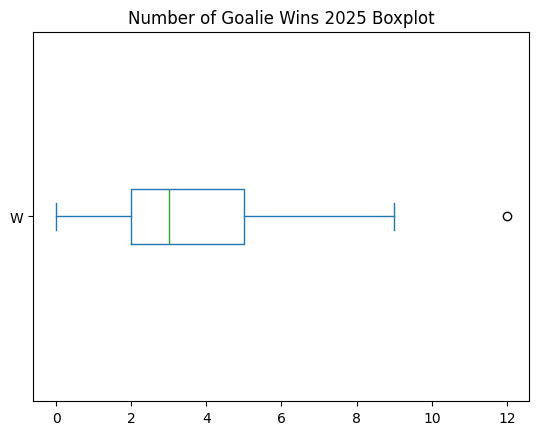

In [14]:
df["W"].plot.box(vert=False, title = "Number of Goalie Wins 2025 Boxplot")

The plot above does not help with Quality Starts, but rather just a general picture as to the landscape of Goalie Wins so far this season (A win is when a goalie finishes a game on the winning team). The median is 3 wins, but it is worth noting the amount of data that is spread out between the median and the maximum (all points excluding the outlier at 12). Roughly 50% of the goalies have between 3 and 9 wins, which is where most of the starting goalies are. The bottom 50% (0-3) wins are all backups, likely on bad teams too, or teams with goalies that get almost all of the starts. There is one "outlier" at 12 wins, which is an outlier in many ways in the context of the NHL Season and this dataset.

The Winnipeg Jets are the team that leads the NHL in wins and had a historic start to the season (15 wins in 16 games), and their starting goalie, Connor Hellebuyck, got 12 of those wins, so it is natural to look at the goalie wins and claim his number of wins are an outlier. However, if you were look at just the starters (filter out backups), there's a chance that the data still claims that this is an outlier, because despite the median increasing by removing lower win totals, the standard deviation gets smaller, so it might still be outside.

<Axes: title={'center': 'Number of Shots Faced vs Quality Starts'}, xlabel='Number of Shots Faced', ylabel='Number of Quality Starts'>

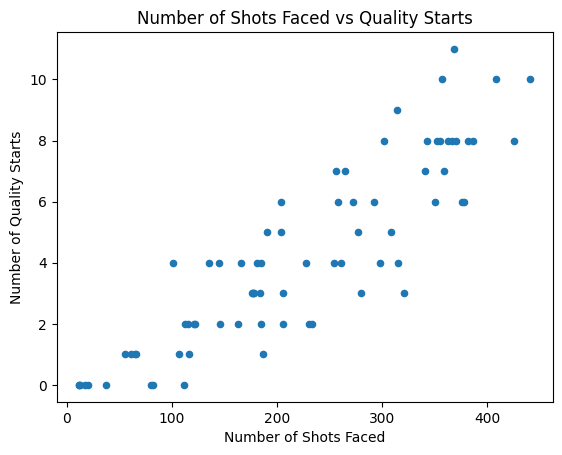

In [15]:
df.plot.scatter(title= "Number of Shots Faced vs Quality Starts", x="Shots", y="QS", xlabel = "Number of Shots Faced", ylabel = "Number of Quality Starts")

Above is a scatterplot to show the correlation of number of shots faced for a goalie and the number of quality starts that goalie has. The assumption is the more shots faced, the more goals likely conceded, and possibly the lower the number of quality starts (as well as save percentage). That is not the case above, as goalies who have a higher amount of shots faced tend to have a higher number of quality starts. However, this could be due to the fact that goalies that play more will face more shots and will also have more chances at obtaining a quality start.

In [16]:
df.sort_values("QS", ascending=False).head(10)

,Rk,Player,Age,Team,Pos,GP,GS,W,L,T/O,...,GA%-,GSAA,GAA/A,GPS,G,A,PTS,PIM,Awards,-9999
7,8.0,Filip Gustavsson,26.0,MIN,G,13.0,13.0,8.0,3.0,2.0,...,74.0,9.5,2.16,3.1,1.0,0.0,1.0,0.0,NaN,gustafi01
2,3.0,Connor Hellebuyck,31.0,WPG,G,14.0,14.0,12.0,2.0,0.0,...,74.0,10.4,2.21,3.5,0.0,0.0,0.0,0.0,NaN,helleco01
0,1.0,Juuse Saros,29.0,NSH,G,15.0,15.0,5.0,8.0,2.0,...,87.0,5.7,2.69,3.2,0.0,1.0,1.0,0.0,NaN,sarosju01
19,20.0,Anthony Stolarz,31.0,TOR,G,12.0,12.0,7.0,3.0,2.0,...,74.0,9.4,2.26,3.1,0.0,0.0,0.0,0.0,NaN,stolaan01
16,17.0,Jake Oettinger,26.0,DAL,G,12.0,12.0,9.0,3.0,0.0,...,84.0,5.1,2.36,2.4,0.0,0.0,0.0,0.0,NaN,oettija01
9,10.0,Petr Mrázek,32.0,CHI,G,13.0,13.0,5.0,8.0,0.0,...,95.0,1.8,2.94,2.4,0.0,0.0,0.0,0.0,NaN,mrazepe01
3,4.0,Jacob Markström,35.0,NJD,G,14.0,14.0,8.0,5.0,1.0,...,94.0,2.2,2.73,2.5,0.0,0.0,0.0,0.0,NaN,marksja02
8,9.0,Kevin Lankinen,29.0,VAN,G,13.0,13.0,8.0,3.0,2.0,...,100.0,0.2,2.87,2.1,0.0,0.0,0.0,0.0,NaN,lankike01
17,18.0,Igor Shesterkin,29.0,NYR,G,12.0,12.0,7.0,4.0,1.0,...,87.0,4.6,2.87,2.7,0.0,0.0,0.0,0.0,NaN,shestig01
5,6.0,Andrei Vasilevskiy,30.0,TBL,G,14.0,14.0,8.0,5.0,1.0,...,81.0,7.0,2.22,2.8,0.0,0.0,0.0,4.0,NaN,vasilan02


The table above does not show the number of quality starts, but is sorted by that statistic. We can find the number of quality starts from the scatterplot above that if we want specific numbers. We can also see that several goalies that are top 10 in quality starts this season have a good amount of wins (7 or more), and Hellebuyck is 2nd in Quality starts, so he is playing his part while racking up an abnormally higher number of wins. However, there are a couple goalies that have 5 or fewer wins in the top 10, Saros and Mrazek. This indicates that the goalies are either facing an high number of shots or/and their teams are not able to score at a high enough rate to match that.

<Axes: title={'center': 'Number of Shots Faced vs Wins'}, xlabel='Number of Shots Faced', ylabel='Number of Wins'>

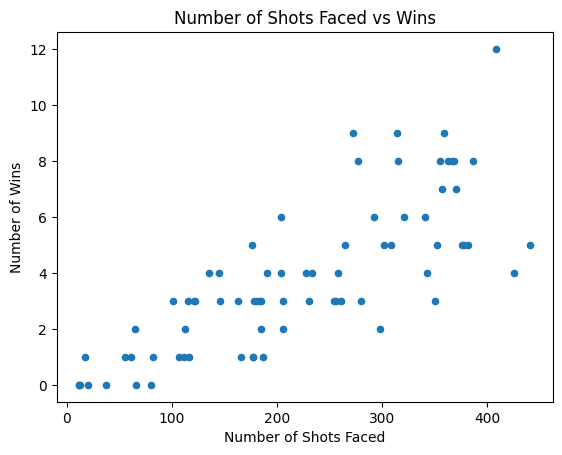

In [17]:
df.plot.scatter(title= "Number of Shots Faced vs Wins", x="Shots", y="W", xlabel = "Number of Shots Faced", ylabel = "Number of Wins")

Above is the scatterplot that shows the Number of Shots a goalie has faced this season versus the Number of Wins the goalie has. The trend seems to be that more shots faced indicates more wins for a goalie, which is a fascinating concept because it sounds counterintuitive, but it is those goalies who face more shots who tend to play more which is why they often will get more wins. The table below which shows the ten goalies with the most shots faced will point out some key takeaways about certain goalies that can be seen in the scatterplot above.

In [18]:
df.sort_values("Shots", ascending=False).head(10)

,Rk,Player,Age,Team,Pos,GP,GS,W,L,T/O,...,GA%-,GSAA,GAA/A,GPS,G,A,PTS,PIM,Awards,-9999
0,1.0,Juuse Saros,29.0,NSH,G,15.0,15.0,5.0,8.0,2.0,...,87.0,5.7,2.69,3.2,0.0,1.0,1.0,0.0,NaN,sarosju01
12,13.0,Lukáš Dostál,24.0,ANA,G,12.0,12.0,4.0,6.0,2.0,...,78.0,9.1,2.92,3.4,0.0,0.0,0.0,0.0,NaN,dostalu01
2,3.0,Connor Hellebuyck,31.0,WPG,G,14.0,14.0,12.0,2.0,0.0,...,74.0,10.4,2.21,3.5,0.0,0.0,0.0,0.0,NaN,helleco01
3,4.0,Jacob Markström,35.0,NJD,G,14.0,14.0,8.0,5.0,1.0,...,94.0,2.2,2.73,2.5,0.0,0.0,0.0,0.0,NaN,marksja02
9,10.0,Petr Mrázek,32.0,CHI,G,13.0,13.0,5.0,8.0,0.0,...,95.0,1.8,2.94,2.4,0.0,0.0,0.0,0.0,NaN,mrazepe01
1,2.0,Jordan Binnington,31.0,STL,G,14.0,13.0,5.0,7.0,1.0,...,115.0,-5.6,3.35,1.7,0.0,0.0,0.0,0.0,NaN,binnijo01
10,11.0,Jeremy Swayman,26.0,BOS,G,13.0,13.0,5.0,6.0,2.0,...,113.0,-4.8,3.51,1.7,0.0,0.0,0.0,0.0,NaN,swaymje01
17,18.0,Igor Shesterkin,29.0,NYR,G,12.0,12.0,7.0,4.0,1.0,...,87.0,4.6,2.87,2.7,0.0,0.0,0.0,0.0,NaN,shestig01
7,8.0,Filip Gustavsson,26.0,MIN,G,13.0,13.0,8.0,3.0,2.0,...,74.0,9.5,2.16,3.1,1.0,0.0,1.0,0.0,NaN,gustafi01
11,12.0,Joey Daccord,28.0,SEA,G,12.0,12.0,8.0,3.0,1.0,...,83.0,6.3,2.59,2.8,0.0,0.0,0.0,0.0,NaN,daccojo01


The table above does not show the number of shots faced, but is sorted by that statistic. Similar to the number of quality starts, we can find the (approximate) number of shots faced from the scatterplot above that if we want specific numbers. Unlike the Quality Starts chart, there are not as many goalies here with 7 or more wins, because facing shots does not mean that the goalie saved them all or even a good amount. Only half the goalies have 7 or more wins while facing the most shots.

# Planning for Part II

As shown in the Quality Starts vs Wins charts, Juuse Saros seems to have a team that allows many shots and cannot score enough goals the other end. Since both Saros and Peter Mrazek were top 10 in shots faced and quality starts, while having fewer than 7 wins, we can potentially guess that this is a case of their respective teams not scoring enough goals to help them win.

Goalies that have been winning with quality starts and the large number of shots (Gustavsson, Shesterkin, Markstrom) are on teams that can put up wins with enough goal support if their goalies play well enough. Finally, Connor Hellebuyck, who has been proven as an outlier, is also on the boat of goalies who have been winning with quality starts. But with the higher number of shots faced, quality starts and wins, combined with the fact he is widely regarded as one of if not the best goalie in the NHL, Hellebuyck might be on another level that will be considered as an outlier in NHL Goalie Data for the 2024-25 season.

Since the next part will be done in a few weeks from now, it is worth checking back how Hellebuyck is doing and if his win totals are sustainable, even with his strong performances. On the flip side, it is worth seeing if goalies with low win totals with strong performances (Saros and Mrazek) will have a positive regression for wins. It is also worth comparing quality starts to goals allowed, because quality starts checks on save percentage and does not entirely highlight goals conceded (e.g. a goalie can have 45 saves, but 4 goals conceded and that might be a quality start) and I also want to find out how much offensive support goalies are getting. We can assume that it is not much for Saros and Mrazek, but we can also extract that data and analyze it too.

# Data Science

One of my questions from the previous part was, "Is it worth separating quality starts and goals conceded?". More specifically, when looking at a goalie and they have a certain number of quality starts, is it because of the amount of saves made or the lack of goals conceded (or both). As mentioned above, goalies can get quality starts by having a large number of saves (e.g. 45 saves but 4 goals conceded) vs a lower number of goals allowed (1 goal conceded, 19 saves). Goalies that face more shots are more likely to allow more goals, so the best goalies are the ones that face the most shots and concede the least amount of goals. We can achieve this by creating a model that analyzes the amount of goals that are expected to be conceded (per league statistics) given a certain amount of shots faced, number of games started, and the number of goals allowed. We are adding games started to help give context to the number of shots faced (if a goalie starts more, they will face more shots).

In [40]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

ind = df[["Shots", "GA", "GS"]]
dep = df["QS"]

model.fit(ind, dep)
df["xQS"] = model.predict(ind)
df["QSAE"] = df["QS"] - df["xQS"]

Now that we fit a model based on the number quality starts to shots faced and goals allowed, we can use it to predict the number of expected quality starts a goalie should have based on those two factors and then calculate which ones are having more quality starts than expected.

In [43]:
df.sort_values("xQS", ascending=False).head(10)

,Rk,Player,Age,Team,Pos,GP,GS,W,L,T/O,...,GAA/A,GPS,G,A,PTS,PIM,Awards,-9999,xQS,QSAE
2,3.0,Connor Hellebuyck,31.0,WPG,G,14.0,14.0,12.0,2.0,0.0,...,2.21,3.5,0.0,0.0,0.0,0.0,NaN,helleco01,10.557376,-0.557376
5,6.0,Andrei Vasilevskiy,30.0,TBL,G,14.0,14.0,8.0,5.0,1.0,...,2.22,2.8,0.0,0.0,0.0,4.0,NaN,vasilan02,9.806408,-1.806408
7,8.0,Filip Gustavsson,26.0,MIN,G,13.0,13.0,8.0,3.0,2.0,...,2.16,3.1,1.0,0.0,1.0,0.0,NaN,gustafi01,9.791282,1.208718
0,1.0,Juuse Saros,29.0,NSH,G,15.0,15.0,5.0,8.0,2.0,...,2.69,3.2,0.0,1.0,1.0,0.0,NaN,sarosju01,9.783353,0.216647
19,20.0,Anthony Stolarz,31.0,TOR,G,12.0,12.0,7.0,3.0,2.0,...,2.26,3.1,0.0,0.0,0.0,0.0,NaN,stolaan01,9.134917,0.865083
12,13.0,Lukáš Dostál,24.0,ANA,G,12.0,12.0,4.0,6.0,2.0,...,2.92,3.4,0.0,0.0,0.0,0.0,NaN,dostalu01,8.754391,-0.754391
3,4.0,Jacob Markström,35.0,NJD,G,14.0,14.0,8.0,5.0,1.0,...,2.73,2.5,0.0,0.0,0.0,0.0,NaN,marksja02,8.398843,-0.398843
11,12.0,Joey Daccord,28.0,SEA,G,12.0,12.0,8.0,3.0,1.0,...,2.59,2.8,0.0,0.0,0.0,0.0,NaN,daccojo01,8.236041,-0.236041
16,17.0,Jake Oettinger,26.0,DAL,G,12.0,12.0,9.0,3.0,0.0,...,2.36,2.4,0.0,0.0,0.0,0.0,NaN,oettija01,8.153524,0.846476
17,18.0,Igor Shesterkin,29.0,NYR,G,12.0,12.0,7.0,4.0,1.0,...,2.87,2.7,0.0,0.0,0.0,0.0,NaN,shestig01,7.775192,0.224808


Above is the top 10 goalies in expected quality starts (based on the model) and below is top 10 in quality starts above expected.

In [60]:
df.sort_values("QSAE", ascending=True).head(10)

,Rk,Player,Age,Team,Pos,GP,GS,W,L,T/O,...,GAA/A,GPS,G,A,PTS,PIM,Awards,-9999,xQS,QSAE
5,6.0,Andrei Vasilevskiy,30.0,TBL,G,14.0,14.0,8.0,5.0,1.0,...,2.22,2.8,0.0,0.0,0.0,4.0,NaN,vasilan02,9.806408,-1.806408
14,15.0,Connor Ingram,27.0,UTA,G,12.0,12.0,6.0,3.0,3.0,...,3.57,1.2,0.0,0.0,0.0,2.0,NaN,ingraco01,4.724366,-1.724366
37,38.0,Anton Forsberg,32.0,OTT,G,8.0,8.0,3.0,4.0,0.0,...,2.90,1.3,0.0,0.0,0.0,0.0,NaN,forsban01,4.619527,-1.619527
13,14.0,Adin Hill,28.0,VEG,G,12.0,12.0,8.0,3.0,1.0,...,3.34,1.4,0.0,0.0,0.0,0.0,NaN,hillad01,5.415640,-1.415640
24,25.0,Alexandar Georgiev,28.0,COL,G,10.0,10.0,4.0,5.0,0.0,...,3.79,0.5,0.0,1.0,1.0,0.0,NaN,georgal01,3.285666,-1.285666
44,45.0,Alex Lyon,32.0,DET,G,7.0,6.0,2.0,4.0,0.0,...,3.29,1.3,0.0,0.0,0.0,2.0,NaN,lyonal01,3.256762,-1.256762
53,54.0,Casey DeSmith,33.0,DAL,G,5.0,4.0,2.0,2.0,0.0,...,1.79,1.0,0.0,0.0,0.0,2.0,NaN,desmica01,3.061477,-1.061477
57,58.0,Joseph Woll,26.0,TOR,G,5.0,5.0,3.0,2.0,0.0,...,2.60,0.7,0.0,0.0,0.0,0.0,NaN,wolljo01,2.866807,-0.866807
33,34.0,Logan Thompson,27.0,WSH,G,9.0,9.0,8.0,0.0,1.0,...,2.74,2.0,0.0,0.0,0.0,0.0,NaN,thomplo01,5.817065,-0.817065
12,13.0,Lukáš Dostál,24.0,ANA,G,12.0,12.0,4.0,6.0,2.0,...,2.92,3.4,0.0,0.0,0.0,0.0,NaN,dostalu01,8.754391,-0.754391


In [44]:
df.sort_values("QSAE", ascending=False).head(10)

,Rk,Player,Age,Team,Pos,GP,GS,W,L,T/O,...,GAA/A,GPS,G,A,PTS,PIM,Awards,-9999,xQS,QSAE
34,35.0,Daniel Vladař,27.0,CGY,G,9.0,9.0,3.0,4.0,2.0,...,2.76,1.6,0.0,1.0,1.0,0.0,NaN,vladada01,5.337780,1.662220
46,47.0,Cayden Primeau,25.0,MTL,G,7.0,5.0,1.0,2.0,1.0,...,5.00,0.0,0.0,0.0,0.0,2.0,NaN,primeca01,-0.342896,1.342896
21,22.0,Samuel Ersson,25.0,PHI,G,11.0,10.0,5.0,2.0,2.0,...,2.80,1.6,0.0,0.0,0.0,0.0,NaN,erssosa01,5.672429,1.327571
27,28.0,David Rittich,32.0,LAK,G,10.0,9.0,6.0,4.0,0.0,...,2.63,1.0,0.0,0.0,0.0,0.0,NaN,rittida01,4.703122,1.296878
7,8.0,Filip Gustavsson,26.0,MIN,G,13.0,13.0,8.0,3.0,2.0,...,2.16,3.1,1.0,0.0,1.0,0.0,NaN,gustafi01,9.791282,1.208718
28,29.0,Cam Talbot,37.0,DET,G,10.0,9.0,5.0,3.0,1.0,...,2.53,2.6,0.0,0.0,0.0,0.0,NaN,talboca01,6.939783,1.060217
4,5.0,Sam Montembeault,28.0,MTL,G,14.0,13.0,5.0,8.0,1.0,...,3.27,2.0,0.0,0.0,0.0,0.0,NaN,montesa01,6.941476,1.058524
45,46.0,Calvin Pickard,32.0,EDM,G,7.0,6.0,4.0,2.0,0.0,...,2.65,0.7,0.0,0.0,0.0,0.0,NaN,pickaca01,2.968838,1.031162
23,24.0,Ilya Sorokin,29.0,NYI,G,11.0,11.0,4.0,4.0,3.0,...,2.79,2.4,0.0,0.0,0.0,0.0,NaN,sorokil01,7.029728,0.970272
19,20.0,Anthony Stolarz,31.0,TOR,G,12.0,12.0,7.0,3.0,2.0,...,2.26,3.1,0.0,0.0,0.0,0.0,NaN,stolaan01,9.134917,0.865083


# A Different Data Visualization

<Axes: title={'center': 'Quality Starts Expected vs Actual'}, xlabel='Expected Number of Quality Starts', ylabel='Number of Quality Starts'>

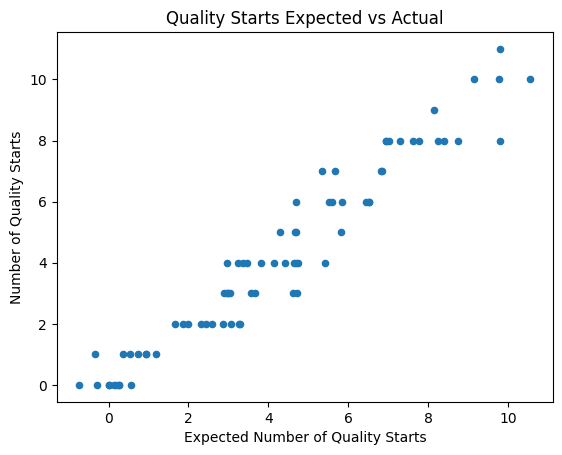

In [52]:
df.plot.scatter(title= "Quality Starts Expected vs Actual", x="xQS", y="QS", xlabel = "Expected Number of Quality Starts", ylabel = "Number of Quality Starts")

<Axes: title={'center': 'Number of Goals Allowed (Average)'}, xlabel='Goals Allowed (Average)', ylabel='Frequency'>

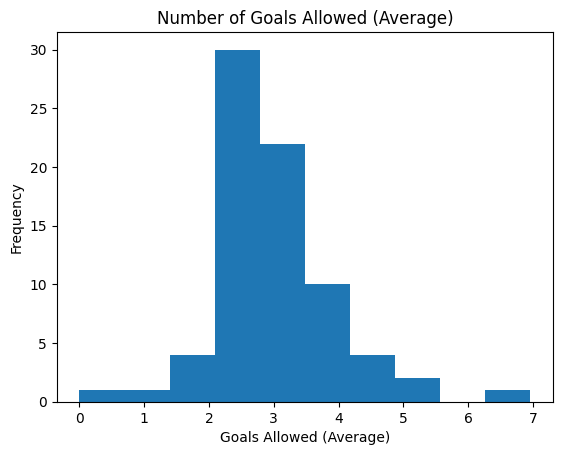

In [59]:
df["GAA"].plot.hist(title = "Number of Goals Allowed (Average)", xlabel = "Goals Allowed (Average)", ylabel = "Frequency")

Above, we have two plots. The first one is a scatterplot of expected number of quality starts to actual quality starts. The linear trend shows that the model created earlier did an adequate job of fitting the statistics for goalies this season to help predict the expected number of quality starts. The second plot is a histogram of Goals Allowed (Average). This will give us an idea later as to the average amount of goals allowed on average. Most of the goalies have a GAA between 2 and 4 (even more so 2 and 3).

# Overall Summary

We fitted a model that uses the number of goalie starts, goals allowed, and shots faced to predict the number of quality starts that goalie will have up to this point. Goalies like Connor Hellebuyck and Filip Gustavsson led this list, unsurprisingly, as they led the list in actual quality starts. Goalies like Andrei Vasilevskiy were high in expected quality starts, but were lower in actual quality starts. His GAA is 2.22, which is on the lower side of goalies, indicating he also does not need to make a ton of saves to reach his quality start, given that average goals allowed. With the underperformance, Vasilevskiy is at the bottom of Quality starts above expected (meaning he should have more according to the model than he actually does). Two other names worth noting in the "QSAE" tables are Filip Gustavsson and Anthony Stolarz. Both are top 5 in QSAE, meaning that they are overperforming (according to the model) and they are top 5 in actual QS as well, meaning that they both have had superb starts, but if they have the same rate of games started, shots faced, and goals conceded over a certain span, they should be regressing in the number of quality starts. 

The one goalie worth noting about again is Connor Hellebuyck. Noted as one of the best goalies in hockey, we analyzed earlier that he and the Winnipeg Jets were having a historic start and that it was due for regression (atleast in the win's column). According to the model, Helleybuck is not due for regression. He does face a large number of shots and saves a large number of them, but not to the point where he is overperforming, compared to the league average. Hellebuyck is not on either top 10 QSAE tables for underperformance or overperformance, and yet he still leads the league in expected number of quality starts, as he is top 3 in shots faced and quality starts, and his GAA is 2.21, which is likely in the upper tier for goalies (less is better here). There might be other factors, like goal support or low danger shots faced (aka easy shots faced) that Hellebuyck has dealt with that might explain for his hot start, but the model we created suggests that with his pace of games started, goals allowed, and shots faced, it is not an over or even underperformance and there is no suggestion of regression for him.